In [1]:
import numpy as np

In [2]:
print(np.__version__)

2.4.4


In [ ]:
#!pip uninstall numpy -y
#!pip install numpy<2 --no-cache-dir

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder,MinMaxScaler,RobustScaler
import warnings
import matplotlib.pyplot as plt

In [4]:
warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv("loan_approved.csv")

In [6]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Loan_ID                 614 non-null    str    
 1   Gender                  601 non-null    str    
 2   Married                 611 non-null    str    
 3   Dependents              599 non-null    str    
 4   Education               614 non-null    str    
 5   Self_Employed           582 non-null    str    
 6   ApplicantIncome         614 non-null    int64  
 7   CoapplicantIncome       614 non-null    float64
 8   LoanAmount              592 non-null    float64
 9   Loan_Amount_Term        600 non-null    float64
 10  Credit_History          564 non-null    float64
 11  Property_Area           614 non-null    str    
 12  Loan_Status (Approved)  614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [8]:
df.isnull().sum()

Loan_ID                    0
Gender                    13
Married                    3
Dependents                15
Education                  0
Self_Employed             32
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                22
Loan_Amount_Term          14
Credit_History            50
Property_Area              0
Loan_Status (Approved)     0
dtype: int64

#### Data Cleaning
- Dropping columns: dropna(), drop(), drop_duplicates()
- Filling/Imputing: fillna(), or impute manually
- Winsorization

In [9]:
df.duplicated().sum()   #To get the number of duplicate rows
# df.drop_duplicates()    #To remove or delete or drop duplicate rows from data

np.int64(0)

In [10]:
df.shape

(614, 13)

In [11]:
#df.drop('Gender',axis=1,inplace=True)
df.dropna()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
#Null columns: 'Gender','Dependents','Self_Employed','LoanAmount','Loan_Amount_Term','Credit_History'

#df.fillna(value = {'Gender': 'F','LoanAmount':np.mean(df.LoanAmount),'Credit_History':df.Credit_History.median()})
#df.fillna(0)

#df.loc[df.LoanAmount.isnull(),'LoanAmount'] = df.LoanAmount.mean()  # - Each individual column can be imputed separately

In [12]:
df.Loan_Amount_Term.value_counts()

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
240.0      4
84.0       4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [15]:
df.Dependents.value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [18]:
df.fillna(value = {'Gender': 'Male','LoanAmount':df.LoanAmount.median(),'Credit_History':df.Credit_History.min(),'Dependents':'0','Self_Employed':'No','Loan_Amount_Term':360.0,'Married':'No'},inplace=True)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved)
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [19]:
df.isnull().sum()

Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History            0
Property_Area             0
Loan_Status (Approved)    0
dtype: int64

In [ ]:
df.Married.value_counts()

In [ ]:
df.loc[df.Married.isnull(),'Married'] = 'Yes'
#df.loc[(df.Married.isnull()&df.Dependents=='0'),'Married']='No'
#df.loc[(df.Married.isnull()&df.Dependents!='0'),'Married']='Yes'
#df.loc[(df.Married.isnull()&df.CoapplicantIncome==0),'Married']='No'
#df.loc[(df.Married.isnull()&df.CoapplicantIncome!=0),'Married']='Yes'

In [ ]:
df.isnull().sum()

### Outlier Handling

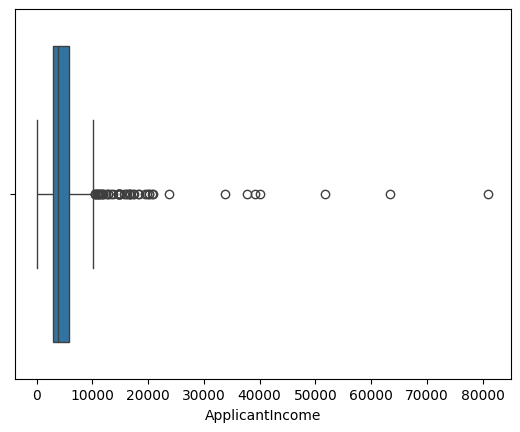

In [21]:
#Winsorization
sns.boxplot(x=df.ApplicantIncome ,orient='h')
plt.show()

In [30]:
from scipy.stats.mstats import winsorize
#Specify trim percentage
trim_p = 0.08
df['ApplicantIncome1'] = winsorize(df['ApplicantIncome'],limits=trim_p)

In [28]:
# Example for winsorize

from scipy.stats.mstats import winsorize
#Specify trim percentage
trim_right = 0.25
trim_left= 0.2
data = np.array([2,5,10,20,30,40,50,600,10000])

print(winsorize(data,limits=[trim_left,trim_right]))

[ 5  5 10 20 30 40 50 50 50]


<Axes: xlabel='ApplicantIncome1'>

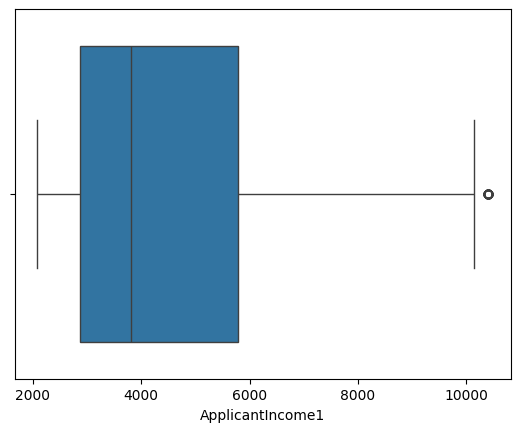

In [31]:
sns.boxplot(x=df.ApplicantIncome1 ,orient='h')

In [ ]:
#Manually setting limits
df.loc[df.ApplicantIncome>20000,'ApplicantIncome'] = 20000

In [33]:
#Removing Outliers using IQR

Q1 = df['LoanAmount'].quantile(0.25)
Q3 = df['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping outliers
df.loc[(df['LoanAmount'] <= lower_bound),'LoanAmount'] = lower_bound
df.loc[(df['LoanAmount'] >= upper_bound),'LoanAmount'] = upper_bound

<Axes: xlabel='LoanAmount'>

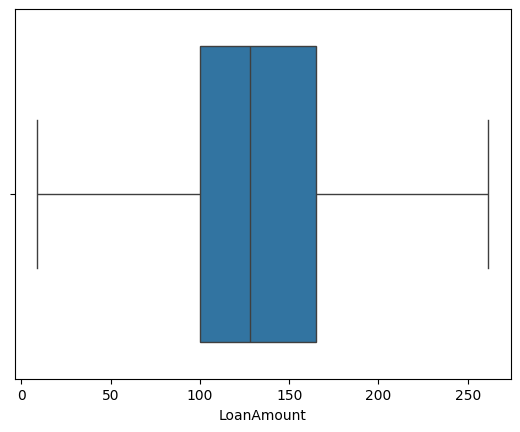

In [34]:
sns.boxplot(x=df.LoanAmount ,orient='h')

## Types Of Transformation

1. Logarithmic Transformation
2. Exponential Transformation
3. Box Cox Transformation
4. Square Root Transformation

In [36]:
data_log = [1,10,100,1000,10000]
print(data_log)
for data in data_log:
    print(np.log(data))

[1, 10, 100, 1000, 10000]
0.0
2.302585092994046
4.605170185988092
6.907755278982137
9.210340371976184


In [ ]:
df['CoapplicantIncome_log'] = np.log(df['CoapplicantIncome'])
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
sns.histplot(x=df['CoapplicantIncome'], kde= True)
plt.subplot(1,2,2)
sns.histplot(x=df['CoapplicantIncome_log'], kde= True)
plt.tight_layout()

<Axes: xlabel='ApplicantIncome_exp2', ylabel='Count'>

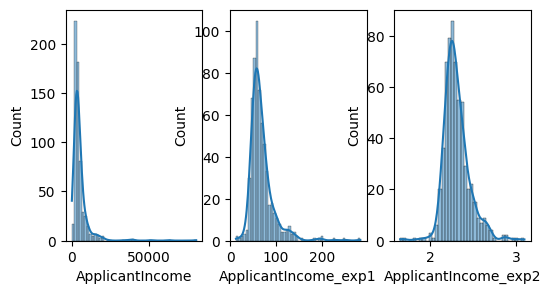

In [37]:
df['ApplicantIncome_exp1']=df.ApplicantIncome**(0.5)
df['ApplicantIncome_exp2']=df.ApplicantIncome**(0.1)
plt.figure(figsize=(6,3))
plt.subplot(1,3,1)
sns.histplot(x=df['ApplicantIncome'], kde= True)
plt.subplot(1,3,2)
sns.histplot(x=df['ApplicantIncome_exp1'], kde= True)
plt.subplot(1,3,3)
sns.histplot(x=df['ApplicantIncome_exp2'], kde= True)

In [ ]:
from scipy.stats import boxcox
transformed_data, lambda_value = boxcox(df['ApplicantIncome'])

In [ ]:
transformed_data

In [ ]:
lambda_value

In [ ]:
df['ApplicantIncome_boxcox'] = transformed_data
plt.figure(figsize=(4,2))
plt.subplot(1,2,1)
sns.histplot(x=df['ApplicantIncome'], kde= True)
plt.subplot(1,2,2)
sns.histplot(x=df['ApplicantIncome_boxcox'], kde= True)

In [38]:
#from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),ApplicantIncome1,ApplicantIncome_exp1,ApplicantIncome_exp2
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849,76.478755,2.380719
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,4583,67.697858,2.323352
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000,54.772256,2.226959
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,2583,50.823223,2.193878
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000,77.459667,2.386795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900,53.851648,2.219422
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106,64.078077,2.297957
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8072,89.844310,2.458658
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583,87.080423,2.443341


In [41]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings

In [42]:
warnings.filterwarnings("ignore")

# 1. Load the real-world dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [45]:

# Split into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [46]:
print("--- TRAINING THE MODEL ---")
# Train the model using the CORRECT method
scaler_correct = StandardScaler()
X_train_scaled = scaler_correct.fit_transform(X_train)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model successfully trained on scaled training data.\n")


--- TRAINING THE MODEL ---
Model successfully trained on scaled training data.



In [49]:
print("--- SCENARIO 1: The Test Set Accuracy ---")
# CORRECT WAY: Only transform() the test data
X_test_correct = scaler_correct.transform(X_test)
acc_correct = accuracy_score(y_test, model.predict(X_test_correct))
print(acc_correct)

--- SCENARIO 1: The Test Set Accuracy ---
0.9736842105263158


In [50]:
scaler_incorrect = StandardScaler()
X_test_incorrect = scaler_incorrect.fit_transform(X_test) 
acc_incorrect = accuracy_score(y_test, model.predict(X_test_incorrect))

print(f"Correct Accuracy (transform): {acc_correct * 100:.2f}%")
print(f"Incorrect Accuracy (fit_transform): {acc_incorrect * 100:.2f}%")
print("Notice how the incorrect method drops accuracy because the test data was scaled using different parameters.\n")

Correct Accuracy (transform): 97.37%
Incorrect Accuracy (fit_transform): 98.25%
Notice how the incorrect method drops accuracy because the test data was scaled using different parameters.



In [51]:
print("--- SCENARIO 2: The Data Value Shift ---")
# Let's look at the very first feature of the very first patient in the test set
feature_name = X_train.columns[0] # 'mean radius'
print(f"Patient 1 '{feature_name}' raw value: {X_test.iloc[0, 0]:.4f}")
print(f"Patient 1 '{feature_name}' scaled correctly: {X_test_correct[0, 0]:.4f}")
print(f"Patient 1 '{feature_name}' scaled incorrectly: {X_test_incorrect[0, 0]:.4f}")
print("The model evaluates the patient based on a different number entirely!\n")


print("--- SCENARIO 3: The Production Crash ---")
# Imagine a new patient arrives at your hospital and you process them individually.
single_patient = X_test.iloc[[0]] 

try:
    # INCORRECT WAY: Attempting to fit_transform a single patient
    single_patient_bad_scale = scaler_incorrect.fit_transform(single_patient)
    print("If you fit on a single row, the variance is 0.")
    print("StandardScaler formula is (x - mean) / standard_deviation.")
    print(f"Resulting data array:\n{single_patient_bad_scale[0][:5]} ... (All zeros!)")
    print("Your model will predict everything as the exact same class.")
except Exception as e:
    print(f"Error: {e}")


--- SCENARIO 2: The Data Value Shift ---
Patient 1 'mean radius' raw value: 12.4700
Patient 1 'mean radius' scaled correctly: -0.4665
Patient 1 'mean radius' scaled incorrectly: -0.4878
The model evaluates the patient based on a different number entirely!

--- SCENARIO 3: The Production Crash ---
If you fit on a single row, the variance is 0.
StandardScaler formula is (x - mean) / standard_deviation.
Resulting data array:
[0. 0. 0. 0. 0.] ... (All zeros!)
Your model will predict everything as the exact same class.


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
ApplicantIncome_scaled = scaler.fit_transform(df[['ApplicantIncome']])

In [40]:
ApplicantIncome_scaled

array([[ 7.29908229e-02],
       [-1.34411954e-01],
       [-3.93747337e-01],
       [-4.62062470e-01],
       [ 9.77284368e-02],
       [ 2.21831139e-03],
       [-5.03018784e-01],
       [-3.87849628e-01],
       [-2.28939128e-01],
       [ 1.21845703e+00],
       [-3.60982286e-01],
       [-4.75659966e-01],
       [-3.81788093e-01],
       [-5.81654908e-01],
       [-6.72414101e-01],
       [-7.42880841e-02],
       [-2.96107483e-01],
       [-3.10196456e-01],
       [-8.46090753e-02],
       [-4.59277440e-01],
       [ 3.69678365e-01],
       [ 9.03563002e-02],
       [-4.59277440e-01],
       [-3.33951118e-01],
       [-2.76284627e-01],
       [ 6.80946355e-01],
       [-4.26676214e-01],
       [-1.92897571e-01],
       [-6.48987089e-01],
       [-2.70878394e-01],
       [-2.02727086e-01],
       [-3.66388519e-01],
       [-1.16555001e-01],
       [-3.11834708e-01],
       [ 1.16259261e+00],
       [-5.12520649e-01],
       [-5.85750540e-01],
       [-2.84475890e-01],
       [-2.0

In [54]:
from sklearn.preprocessing import MinMaxScaler
ApplicantIncome_scaled2 = MinMaxScaler().fit_transform(df[['ApplicantIncome']])
# ApplicantIncome_scaled2 = scaler.fit_transform(df[['ApplicantIncome']])
ApplicantIncome_scaled2

array([[7.04885591e-02],
       [5.48299320e-02],
       [3.52504638e-02],
       [3.00927644e-02],
       [7.23562152e-02],
       [6.51453309e-02],
       [2.70006184e-02],
       [3.56957328e-02],
       [4.76932591e-02],
       [1.56969697e-01],
       [3.77241806e-02],
       [2.90661719e-02],
       [3.61533704e-02],
       [2.10636982e-02],
       [1.42115028e-02],
       [5.93692022e-02],
       [4.26221398e-02],
       [4.15584416e-02],
       [5.85899814e-02],
       [3.03030303e-02],
       [9.28880643e-02],
       [7.17996289e-02],
       [3.03030303e-02],
       [3.97649969e-02],
       [4.41187384e-02],
       [1.16388374e-01],
       [3.27643785e-02],
       [5.04143476e-02],
       [1.59802103e-02],
       [4.45269017e-02],
       [4.96722325e-02],
       [3.73160173e-02],
       [5.61781076e-02],
       [4.14347557e-02],
       [1.52752010e-01],
       [2.62832406e-02],
       [2.07544836e-02],
       [4.35003092e-02],
       [4.96722325e-02],
       [4.45021645e-02],


In [55]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
ApplicantIncome_scaled3 = scaler.fit_transform(df[['ApplicantIncome']])
ApplicantIncome_scaled3

array([[ 6.98029135e-01],
       [ 2.64095973e-01],
       [-2.78491859e-01],
       [-4.21422451e-01],
       [ 7.49785775e-01],
       [ 5.49957155e-01],
       [-5.07112254e-01],
       [-2.66152528e-01],
       [ 6.63239075e-02],
       [ 3.09460154e+00],
       [-2.09940017e-01],
       [-4.49871465e-01],
       [-2.53470437e-01],
       [-6.71636675e-01],
       [-8.61525278e-01],
       [ 3.89888603e-01],
       [-7.42073693e-02],
       [-1.03684662e-01],
       [ 3.68294773e-01],
       [-4.15595544e-01],
       [ 1.31876607e+00],
       [ 7.34361611e-01],
       [-4.15595544e-01],
       [-1.53384747e-01],
       [-3.27335047e-02],
       [ 1.97000857e+00],
       [-3.47386461e-01],
       [ 1.41730934e-01],
       [-8.12510711e-01],
       [-2.14224507e-02],
       [ 1.21165381e-01],
       [-2.21251071e-01],
       [ 3.01456727e-01],
       [-1.07112254e-01],
       [ 2.97772065e+00],
       [-5.26992288e-01],
       [-6.80205656e-01],
       [-4.98714653e-02],
       [ 1.2

### Encoding
- Converting categorical variables into numerical so that the model can process them
- OHE (one hot encoding) - Create as many columns as unique values of the categorical feature. Done to those features that cannot(shouldn't) have an ordinality.
- Label Encoding - Let the default lexicographic (alphabetical order) endocing happen. Numbers automatically assigned without any order. Renders a 1-d output (unlike all other scalers and encoders that render a 2d output) as it is designed to encode target columns
- Ordinal Encoding - Speicify the order in which numerical labels must be assigned. Done when the data is ordinal
- Frequency Encoding - Specify the order based on frequency or value_counts

In [56]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Loan_Status (Approved)', 'ApplicantIncome1', 'ApplicantIncome_exp1',
       'ApplicantIncome_exp2'],
      dtype='str')

In [57]:
# OHE - One Hot Encoding
#df.Married.value_counts()
pd.get_dummies(df, columns=['Married'],dtype='int')

,Loan_ID,Gender,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),ApplicantIncome1,ApplicantIncome_exp1,ApplicantIncome_exp2,Married_No,Married_Yes
0,LP001002,Male,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849,76.478755,2.380719,1,0
1,LP001003,Male,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,4583,67.697858,2.323352,0,1
2,LP001005,Male,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000,54.772256,2.226959,0,1
3,LP001006,Male,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,2583,50.823223,2.193878,0,1
4,LP001008,Male,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000,77.459667,2.386795,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900,53.851648,2.219422,1,0
610,LP002979,Male,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106,64.078077,2.297957,0,1
611,LP002983,Male,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8072,89.844310,2.458658,0,1
612,LP002984,Male,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583,87.080423,2.443341,0,1


In [58]:
#OHE from sklearn
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
result = enc.fit_transform(df[['Married']]).toarray()

In [ ]:
pd.DataFrame(result, col)

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]], shape=(614, 2))

In [62]:
df.Married.unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [63]:
result

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       ...,
       [0., 1.],
       [0., 1.],
       [1., 0.]], shape=(614, 2))

In [64]:
#Label Encoder
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
df['Gender_enc'] = enc.fit_transform(df.Gender)
df[['Gender','Gender_enc']]

,Gender,Gender_enc
0,Male,1
1,Male,1
2,Male,1
3,Male,1
4,Male,1
...,...,...
609,Female,0
610,Male,1
611,Male,1
612,Male,1


In [ ]:
enc.fit_transform(df.Gender)

In [65]:
#Frequency encoding using Ordinal Encoder with value_counts
from sklearn.preprocessing import OrdinalEncoder
df.Gender.value_counts()
enc = OrdinalEncoder(categories=[['Male','Female']])
df['Gender_OE1'] = enc.fit_transform(df[['Gender']])


In [66]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status (Approved),ApplicantIncome1,ApplicantIncome_exp1,ApplicantIncome_exp2,Gender_enc,Gender_OE1
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y,5849,76.478755,2.380719,1,0.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,4583,67.697858,2.323352,1,0.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,3000,54.772256,2.226959,1,0.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,2583,50.823223,2.193878,1,0.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,6000,77.459667,2.386795,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y,2900,53.851648,2.219422,0,1.0
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y,4106,64.078077,2.297957,1,0.0
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y,8072,89.844310,2.458658,1,0.0
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y,7583,87.080423,2.443341,1,0.0


In [67]:
#Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder
df.Property_Area.unique()
enc = OrdinalEncoder(categories=[['Rural','Semiurban','Urban']])
df['OE_Prop_Area'] = enc.fit_transform(df[['Property_Area']])
df[['Property_Area','OE_Prop_Area']]

,Property_Area,OE_Prop_Area
0,Urban,2.0
1,Rural,0.0
2,Urban,2.0
3,Urban,2.0
4,Urban,2.0
...,...,...
609,Rural,0.0
610,Rural,0.0
611,Urban,2.0
612,Urban,2.0


In [ ]:
#Frequency encoding using Ordinal Encoder with value_counts
from sklearn.preprocessing import OrdinalEncoder
df.Gender.value_counts()
enc = OrdinalEncoder(categories=[['Male','Female']])
df['Gender_OE1'] = enc.fit_transform(df[['Gender']])

In [ ]:
df.Gender_OE1

In [ ]:
enc.fit_transform(df[['Gender']])

### Feature Creation, Feature Selection, Feature Extraction/Sythesis, Feature Reduction
- Feature creation: Create new columns based on intuition

### PCA - Principal Component Analysis
- Dimensionality curse: After a certain number of columns, distances between the points will become the same. And in that case, the distance based algorithms won't work. In common words, the data has too many features/dependencies that makes it difficult to fit a model, and we are likely to overfit
- In such cases we try to reduce the dimension of the problem (or columns in data). Many techniques are there, principle component Analysis is one of them.
- Correlation is also used to drop columns with high correlation, but when columns aren't correlated with the output, we gotta drop some. We might want to filter them based on relevance to target variable, and the variability within the column.
- PCA comes into picture when all variables are relevant and have no correlation within them.
- Influence of a column on the target variable is found out from the variance within the column. Higher the variance of data in column, higher is the information it contains about target variable, or higher is its influence on target variable.
- Every column is compared to other, we try to shift axis such that variance along one axis shall be maximum and other axis be minumum. In that sense, we drop the axis with minimum variance, and retain the one with maximum variance which is now a function of original two columns. This is called a principle component.
- PCA Algorithm gives all the principal components in ranking order of variance. Each  Within 5-6 components, we can cover 90% of variance of target. In that case, we drop the remaining principal components
- The principal component analysis is an unsupervised machine learning algorithm used for feature selection using dimensionality reduction techniques. As the name suggests, it finds out the principal components from the data. PCA transforms and fits the data from a higher-dimensional space to a new, lower-dimensional subspace This results into an entirely new coordinate system of the points where the first axis corresponds to the first principal component that explains the most variance in the data.

**What are the principal components?**
Principal components are the derived features which explain the maximum variance in the data. The first principal component explains the most variance, the 2nd a bit less and so on. Each of the new dimensions found using PCA is a linear combination of the old features.

## Scree Plots:
Scree plots are the graphs that convey how much variance is explained by corresponding Principal components.


In [ ]:
# importing important labries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
sns.get_dataset_names()

In [ ]:
data = sns.load_dataset('brain_networks')
pd.reset_option('display.max_rows',None)
pd.reset_option('display.max_columns',None)
data

In [ ]:
data.to_csv('output.csv',index=False)

In [ ]:
data = sns.load_dataset('brain_networks').iloc[3:,1:]

In [ ]:
pd.reset_option('display.max_rows',None)
pd.reset_option('display.max_columns',None)
data

In [ ]:
data.reset_index(drop=True,inplace=True)

In [ ]:
data

In [ ]:
#data.info(),data.describe(),data.head(),data.columns,data.isnull().sum()
pd.set_option('display.max_rows',None)
data.isnull().sum()

In [ ]:
pd.reset_option('display.max_rows',None)

In [ ]:
data.info()

In [ ]:
data = data.astype('float')

In [ ]:
data.info()

In [ ]:
# Applying StandardScaler
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaled_data=scaler.fit_transform(data)
col = data.columns
data = pd.DataFrame(data=scaled_data,columns=col)
pd.reset_option('display.max_rows',None)

In [ ]:
scaled_data

In [ ]:
data

In [ ]:
from sklearn.decomposition import PCA
pca = PCA()
PC = pca.fit_transform(data)
PC

In [ ]:
PC.shape

In [ ]:
pca.explained_variance_ratio_

In [ ]:
a  = np.array([1,2,3,3,2,4,5,3,2])
np.cumsum(a)

In [ ]:
np.cumsum(pca.explained_variance_ratio_)

In [ ]:
np.where(np.cumsum(pca.explained_variance_ratio_)>0.9)

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('No. of PC')
plt.ylabel('Explained variance')
plt.title('Explained Variance by PC - Scree plots')
plt.show()
#plt.tight_layout()

In [ ]:
pca2 = PCA(n_components=32)
data_PCA = pd.DataFrame(pca2.fit_transform(data))

In [ ]:
data_PCA.head()